# EBSC Dataset Validation

This notebook validates the processed EBSC HDF5 dataset for a data descriptor-style manuscript. It produces three classes of publication-ready evidence:

1. Sensor synchronization validation: event timestamps, wheel encoder-derived reference velocity, and OptiTrack-derived body velocity are checked on the common dataset time base.
2. Ground-truth validation: OptiTrack, encoder, and slip labels are validated through sampling, kinematic consistency, and slip recomputation checks.
3. Dataset consistency and repeatability: repeated trials with the same command suffix are aligned and overlaid.

The figures are saved as PNG, PDF, and SVG under `validation_figures/`.

## 0. Configuration

Set `PROCESSED_DATA_DIR` to the folder that contains the processed `.h5` files created by the dataset-generation script. Files may be directly in that folder or inside one subfolder per trial.

In [4]:

from pathlib import Path
import json
import math
import re
import warnings

import h5py
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch, FancyArrowPatch
from scipy import signal
from IPython.display import display
from tqdm.auto import tqdm

warnings.filterwarnings("ignore", category=RuntimeWarning)

# -----------------------------------------------------------------------------
# User-editable paths
# -----------------------------------------------------------------------------
PROCESSED_DATA_DIR = Path(r"H:\KU-TII-Soil Project\EBSC_Experiments\Published_Dataset\Dataset")
FIGURE_DIR = Path("validation_figures")
FIGURE_DIR.mkdir(exist_ok=True)

# Example repeated group from the prompt. Leave empty to auto-discover all repeat groups.
REPEATABILITY_GROUPS = {
    # "Vel1_Lev3_ON": [
    #     "2025_07_17_17_19_17_Vel1_Lev3_ON",
    #     "2025_07_21_10_22_29_Vel1_Lev3_ON",
    #     "2025_07_21_10_43_41_Vel1_Lev3_ON",
    # ]
}

# Dataset-generation constants.
WINDOW_SIZE_S = 0.01
WHEEL_RADIUS_M = 0.10
HALF_TRACK_WIDTH_M = 0.22348
HALF_ROVER_LENGTH_M = 0.29
RADIUS_CURVATURE_M = float(np.hypot(HALF_ROVER_LENGTH_M, HALF_TRACK_WIDTH_M))

# Replace these with values from your OptiTrack calibration report and encoder datasheet.
VALIDATION_METADATA = {
    "OptiTrack accuracy": "positional precision of ±0.15 mm",
    "OptiTrack sampling": "Measured in this notebook from the processed 100 Hz time grid; raw ROS timestamps were resampled to 10 ms windows",
    "Wheel encoder resolution": "0.01 dps",
    "Wheel encoder calibration": "Wheel radius = 0.10 m; track half-width = 0.22348 m; signs corrected as [+,+,-,-]",
    "Slip computation": "OptiTrack body-frame velocity and encoder reference velocity synchronized on the event-camera 10 ms time base; encoder reference is low-pass filtered before slip labels are saved",
}

# Nature-style compact figures: vector-friendly, readable after reduction.
mpl.rcParams.update({
    "font.family": "Times New Roman",
    "font.size": 12,
    "axes.labelsize": 12,
    "axes.titlesize": 12,
    "legend.fontsize": 10,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "axes.linewidth": 0.6,
    "xtick.major.width": 0.6,
    "ytick.major.width": 0.6,
    "lines.linewidth": 1.0,
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
})

PALETTE = {
    "event": "#4C78A8",
    "opti": "#2F855A",
    "encoder": "#D95F02",
    "slip": "#7B3294",
    "gray": "#4A5568",
    "light_gray": "#CBD5E0",
}

UNIT_VEL = "m/s"

def save_figure(fig, stem, width_in=None, height_in=None, tight=True):
    if width_in and height_in:
        fig.set_size_inches(width_in, height_in)
    if tight:
        fig.tight_layout(pad=0.45)
    for ext in ("png", "pdf", "svg"):
        fig.savefig(FIGURE_DIR / f"{stem}.{ext}", dpi=600, bbox_inches="tight")
    return FIGURE_DIR / f"{stem}.png"

def finite_pair(x, y):
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)
    keep = np.isfinite(x) & np.isfinite(y)
    return x[keep], y[keep]

def pearson_r(x, y):
    x, y = finite_pair(x, y)
    return float(np.corrcoef(x, y)[0, 1]) if len(x) > 2 else np.nan


## 1. Dataset Discovery and Loading

In [5]:

def trial_suffix(trial_name):
    parts = trial_name.split("_")
    return "_".join(parts[6:]) if len(parts) > 6 and all(p.isdigit() for p in parts[:6]) else trial_name

def parse_trial_metadata(trial_name):
    suffix = trial_suffix(trial_name)
    parts = suffix.split("_")
    velocity = next((p for p in parts if re.match(r"^Vel\d+", p)), "Unknown")
    level = next((p for p in parts if re.match(r"^Lev\d+", p)), "Unknown")
    efficiency = '100' if len(parts) == 3 else parts[1]
    soil_class = level
    lighting = parts[-1] if parts and parts[-1] in {"ON", "OFF"} else "Unknown"
    return {
        "suffix": suffix,
        "soil_class": soil_class,
        "lighting": lighting,
        "velocity_level": velocity,
        "efficiency_condition": efficiency,
    }

def discover_h5_files(root):
    root = Path(root)
    files = sorted(root.rglob("*.h5"))
    if not files:
        raise FileNotFoundError(f"No .h5 files found under {root}. Set PROCESSED_DATA_DIR to the processed dataset folder.")
    return {p.stem: p for p in files}

def get_h5_node(f, *names):
    for name in names:
        if name in f:
            node = f[name]
            if isinstance(node, h5py.Group) and "data" in node:
                return node["data"]
            return node
    raise KeyError(f"None of these datasets were found: {names}. Available keys: {list(f.keys())}")

def read_dataset(f, *names, dtype=np.float32):
    data = get_h5_node(f, *names)[()]
    return np.asarray(data, dtype=dtype)

def make_time_grid(event_info, n_rows, window_size=WINDOW_SIZE_S):
    if event_info["count"] > 1:
        t0 = float(event_info["start_s"])
        t1 = float(event_info["end_s"])
        if np.isfinite(t1 - t0) and t1 > t0:
            t = np.arange(t0, t1, window_size)
            if abs(len(t) - n_rows) <= 2:
                return t[:n_rows]
    return np.arange(n_rows) * window_size

def event_rate_from_h5(events_ds, t, window_size=WINDOW_SIZE_S, chunk_size=1_000_000):
    if events_ds.ndim != 2 or events_ds.shape[1] < 4 or events_ds.shape[0] == 0:
        return np.full_like(t, np.nan, dtype=np.float32)
    bins = np.r_[t, t[-1] + window_size]
    counts = np.zeros(len(t), dtype=np.int64)
    for start in range(0, events_ds.shape[0], chunk_size):
        stop = min(start + chunk_size, events_ds.shape[0])
        timestamps = np.asarray(events_ds[start:stop, 3], dtype=np.float64)
        counts += np.histogram(timestamps, bins=bins)[0]
    return counts.astype(np.float32) / window_size

def event_info_from_h5(events_ds, chunk_size=1_000_000):
    if events_ds.ndim != 2 or events_ds.shape[1] < 4 or events_ds.shape[0] == 0:
        return {"count": 0, "start_s": np.nan, "end_s": np.nan, "timestamps_monotonic": False}
    count = int(events_ds.shape[0])
    start_s = float(events_ds[0, 3])
    end_s = float(events_ds[count - 1, 3])
    monotonic = True
    previous = None
    for start in range(0, count, chunk_size):
        stop = min(start + chunk_size, count)
        timestamps = np.asarray(events_ds[start:stop, 3], dtype=np.float64)
        if previous is not None and len(timestamps) and timestamps[0] < previous:
            monotonic = False
        if len(timestamps) > 1 and np.any(np.diff(timestamps) < 0):
            monotonic = False
        if len(timestamps):
            previous = timestamps[-1]
    return {"count": count, "start_s": start_s, "end_s": end_s, "timestamps_monotonic": monotonic}

def load_processed_trial(path):
    with h5py.File(path, "r") as f:
        events_ds = get_h5_node(f, "events")
        event_info = event_info_from_h5(events_ds)
        opti_pos = read_dataset(f, "Opti_pos", "opti_pos")
        opti_vel = read_dataset(f, "Opti_vel", "opti_vel")
        opti_ori = read_dataset(f, "Opti_ori", "opti_ori")
        opti_ori_rate = read_dataset(f, "Opti_ori_rate", "opti_ori_rate")
        body_vel = read_dataset(f, "vel_body_xy")
        motor_rpm = read_dataset(f, "motor_rpm", "motor_speed")
        ref_velocity = read_dataset(f, "ref_velocity")
        slip = read_dataset(f, "slip")
        n = min(len(opti_pos), len(opti_vel), len(body_vel), len(motor_rpm), len(ref_velocity), len(slip))
        t = make_time_grid(event_info, n)
        rate = event_rate_from_h5(events_ds, t)
    meta = parse_trial_metadata(path.stem)
    return {
        "name": path.stem,
        "path": path,
        "suffix": meta["suffix"],
        "metadata": meta,
        "t": t,
        "event_info": event_info,
        "event_rate": rate,
        "Opti_pos": np.asarray(opti_pos)[:n],
        "Opti_vel": np.asarray(opti_vel)[:n],
        "Opti_ori": np.asarray(opti_ori)[:n],
        "Opti_ori_rate": np.asarray(opti_ori_rate)[:n],
        "vel_body_xy": np.asarray(body_vel)[:n],
        "motor_rpm": np.asarray(motor_rpm)[:n],
        "ref_velocity": np.asarray(ref_velocity)[:n],
        "slip": np.asarray(slip)[:n],
    }

h5_files = discover_h5_files(PROCESSED_DATA_DIR)
trials = {
    name: load_processed_trial(path)
    for name, path in tqdm(h5_files.items(), desc="Loading HDF5 trials", unit="trial")
}
summary = pd.DataFrame([
    {
        "trial": tr["name"],
        "suffix": tr["suffix"],
        "soil_class": tr["metadata"]["soil_class"],
        "lighting": tr["metadata"]["lighting"],
        "velocity_level": tr["metadata"]["velocity_level"],
        "efficiency_condition": tr["metadata"]["efficiency_condition"],
        "duration_s": tr["t"][-1] - tr["t"][0],
        "samples": len(tr["t"]),
        "events": tr["event_info"]["count"],
        "mean_event_rate_Hz": np.nanmean(tr["event_rate"]),
        "mean_body_x_m_s": np.nanmean(tr["vel_body_xy"][:, 0]),
        "mean_ref_x_m_s": np.nanmean(tr["ref_velocity"][:, 0]),
    }
    for tr in trials.values()
])
summary.to_csv(FIGURE_DIR / "dataset_trial_summary.csv", index=False)
summary.head(20)


Loading HDF5 trials: 100%|██████████| 270/270 [22:48<00:00,  5.07s/trial]


,trial,suffix,soil_class,lighting,velocity_level,efficiency_condition,duration_s,samples,events,mean_event_rate_Hz,mean_body_x_m_s,mean_ref_x_m_s
0,2025_07_17_17_19_17_Vel1_Lev3_ON,Vel1_Lev3_ON,Lev3,ON,Vel1,100,40.94,4095,19926847,4.866141e+05,0.021152,0.019409
1,2025_07_21_10_22_29_Vel1_Lev3_ON,Vel1_Lev3_ON,Lev3,ON,Vel1,100,39.51,3952,23042231,5.830524e+05,0.019230,0.019109
2,2025_07_21_10_43_41_Vel1_Lev3_ON,Vel1_Lev3_ON,Lev3,ON,Vel1,100,54.21,5422,24827865,4.579097e+05,0.019256,0.019268
3,2025_07_21_10_52_21_Vel1_Lev3_OFF,Vel1_Lev3_OFF,Lev3,OFF,Vel1,100,58.29,5830,7614486,1.306087e+05,0.020574,0.020359
4,2025_07_21_11_02_18_Vel1_Lev3_OFF,Vel1_Lev3_OFF,Lev3,OFF,Vel1,100,58.90,5891,8549195,1.451230e+05,0.019191,0.019319
5,2025_07_21_11_07_54_Vel1_Lev3_OFF,Vel1_Lev3_OFF,Lev3,OFF,Vel1,100,62.07,6208,7794266,1.255520e+05,0.019672,0.019743
6,2025_07_21_11_21_45_Vel2_Lev3_ON,Vel2_Lev3_ON,Lev3,ON,Vel2,100,39.34,3935,25601523,6.506106e+05,0.031177,0.031092
7,2025_07_21_11_28_46_Vel2_Lev3_ON,Vel2_Lev3_ON,Lev3,ON,Vel2,100,41.20,4121,23915642,5.803359e+05,0.027957,0.026960
8,2025_07_21_11_34_31_Vel2_Lev3_ON,Vel2_Lev3_ON,Lev3,ON,Vel2,100,38.77,3878,23047534,5.943149e+05,0.030724,0.029209
9,2025_07_21_11_40_08_Vel2_Lev3_OFF,Vel2_Lev3_OFF,Lev3,OFF,Vel2,100,37.57,3758,23631435,6.288301e+05,0.030774,0.029752



## 2. Sensor Synchronization Validation

The primary synchronization validation is based on the dataset construction itself: all modalities are represented on the same 10 ms time grid, event timestamps remain monotonic, and each trial has a shared temporal support. Encoder-to-OptiTrack cross-correlation is retained as supporting evidence only, because encoder-derived reference velocity and OptiTrack body velocity measure related but different physical quantities. During wheel slip, acceleration, or braking, non-zero lag can arise from rover dynamics rather than timestamp misalignment.


In [ ]:

def robust_zscore(x):
    x = np.asarray(x, dtype=float)
    med = np.nanmedian(x)
    mad = np.nanmedian(np.abs(x - med))
    scale = 1.4826 * mad if mad > 0 else np.nanstd(x)
    return (x - med) / scale if scale and np.isfinite(scale) else x * np.nan

def estimate_lag_seconds(t, x, y, max_lag_s=1.0):
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)
    valid = np.isfinite(x) & np.isfinite(y)
    x = x[valid]
    y = y[valid]
    if len(x) < 20:
        return np.nan, np.nan, np.array([]), np.array([])
    x = signal.detrend(x)
    y = signal.detrend(y)
    x = x - np.mean(x)
    y = y - np.mean(y)
    corr = signal.correlate(y, x, mode="full")
    lags = signal.correlation_lags(len(y), len(x), mode="full")
    dt = float(np.median(np.diff(t)))
    lag_s = lags * dt
    corr = corr / max(np.sqrt(np.sum(x**2) * np.sum(y**2)), np.finfo(float).eps)
    keep = np.abs(lag_s) <= max_lag_s
    lag_s = lag_s[keep]
    corr = corr[keep]
    if len(corr) == 0:
        return np.nan, np.nan, lag_s, corr
    i = int(np.nanargmax(corr))
    return float(lag_s[i]), float(corr[i]), lag_s, corr

def valid_time_sample_mask(tr):
    arrays = [
        tr["event_rate"],
        tr["ref_velocity"][:, 0],
        tr["vel_body_xy"][:, 0],
        tr["motor_rpm"][:, 0],
        tr["slip"][:, 0],
    ]
    valid = np.ones(len(tr["t"]), dtype=bool)
    for arr in arrays:
        valid &= np.isfinite(np.asarray(arr, dtype=float))
    return valid

def sync_metrics(tr):
    t = tr["t"]
    dt_ms = 1e3 * np.diff(t)
    event_info = tr["event_info"]
    valid_mask = valid_time_sample_mask(tr)
    lag, corr_peak, _, _ = estimate_lag_seconds(t, tr["ref_velocity"][:, 0], tr["vel_body_xy"][:, 0])
    event_duration = float(event_info["end_s"] - event_info["start_s"]) if np.isfinite(event_info["end_s"]) and np.isfinite(event_info["start_s"]) else np.nan
    common_start = max(float(t[0]), float(event_info["start_s"])) if len(t) and np.isfinite(event_info["start_s"]) else np.nan
    common_end = min(float(t[-1]), float(event_info["end_s"])) if len(t) and np.isfinite(event_info["end_s"]) else np.nan
    common_overlap = max(0.0, common_end - common_start) if np.isfinite(common_start) and np.isfinite(common_end) else np.nan
    event_rate = np.asarray(tr["event_rate"], dtype=float)
    return {
        "trial": tr["name"],
        "suffix": tr["suffix"],
        "trial_duration_seconds": float(t[-1] - t[0]) if len(t) > 1 else np.nan,
        "number_of_valid_time_samples": int(np.sum(valid_mask)),
        "percentage_of_valid_samples": float(100 * np.mean(valid_mask)) if len(valid_mask) else np.nan,
        "event_duration_seconds": event_duration,
        "common_time_overlap_seconds": common_overlap,
        "event_rate_mean": float(np.nanmean(event_rate)),
        "event_rate_std": float(np.nanstd(event_rate)),
        "grid_dt_median_ms": float(np.nanmedian(dt_ms)),
        "grid_dt_iqr_ms": float(np.nanpercentile(dt_ms, 75) - np.nanpercentile(dt_ms, 25)),
        "grid_dt_max_abs_deviation_ms": float(np.nanmax(np.abs(dt_ms - 1e3 * WINDOW_SIZE_S))),
        "event_timestamps_monotonic": bool(event_info["timestamps_monotonic"]),
        "event_time_start_s": float(event_info["start_s"]),
        "event_time_end_s": float(event_info["end_s"]),
        "encoder_to_opti_lag_ms": float(1e3 * lag),
        "velocity_corr_peak": float(corr_peak),
    }

sync_table = pd.DataFrame([
    sync_metrics(tr)
    for tr in tqdm(trials.values(), desc="Computing synchronization metrics", unit="trial")
])
sync_table.to_csv(FIGURE_DIR / "sensor_synchronization_metrics.csv", index=False)

CORRELATION_THRESHOLD = np.min(sync_table["velocity_corr_peak"])
valid_corr_trials = sync_table["velocity_corr_peak"] >= CORRELATION_THRESHOLD
low_correlation_trials = sync_table.loc[~valid_corr_trials, [
    "trial", "suffix", "encoder_to_opti_lag_ms", "velocity_corr_peak", "trial_duration_seconds"
]].copy()
low_correlation_trials.to_csv(FIGURE_DIR / "low_correlation_trials.csv", index=False)

valid_lags = sync_table.loc[valid_corr_trials, "encoder_to_opti_lag_ms"].dropna()
valid_corr = sync_table.loc[valid_corr_trials, "velocity_corr_peak"].dropna()
dataset_sync_summary = pd.DataFrame([{
    "n_trials": int(len(sync_table)),
    "percentage_monotonic_event_timestamps": float(100 * sync_table["event_timestamps_monotonic"].mean()),
    "percentage_median_dt_within_0p1_ms_of_10_ms": float(100 * (np.abs(sync_table["grid_dt_median_ms"] - 10.0) <= 0.1).mean()),
    "percentage_valid_time_samples_median": float(sync_table["percentage_of_valid_samples"].median()),
    "percentage_trials_corr_gt_0p6": float(100 * valid_corr_trials.mean()),
    "n_valid_correlation_trials": int(valid_corr_trials.sum()),
    "percentage_valid_correlation_trials": float(100 * valid_corr_trials.mean()),
    "median_lag_ms_valid_corr_trials": float(valid_lags.median()) if len(valid_lags) else np.nan,
    "IQR_lag_ms_valid_corr_trials": float(valid_lags.quantile(0.75) - valid_lags.quantile(0.25)) if len(valid_lags) else np.nan,
    "mean_lag_ms_valid_corr_trials": float(valid_lags.mean()) if len(valid_lags) else np.nan,
    "median_peak_correlation_valid_trials": float(valid_corr.median()) if len(valid_corr) else np.nan,
    "percentage_lag_within_20_ms_valid_trials": float(100 * (np.abs(valid_lags) <= 20).mean()) if len(valid_lags) else np.nan,
    "median_common_time_overlap_seconds": float(sync_table["common_time_overlap_seconds"].median()),
    "median_event_rate_mean": float(sync_table["event_rate_mean"].median()),
}])
dataset_sync_summary.to_csv(FIGURE_DIR / "sensor_synchronization_dataset_summary.csv", index=False)

display(dataset_sync_summary)
sync_table


Computing synchronization metrics: 100%|██████████| 270/270 [00:00<00:00, 472.68trial/s]


,n_trials,percentage_monotonic_event_timestamps,percentage_median_dt_within_0p1_ms_of_10_ms,percentage_valid_time_samples_median,percentage_trials_corr_gt_0p6,n_valid_correlation_trials,percentage_valid_correlation_trials,median_lag_ms_valid_corr_trials,IQR_lag_ms_valid_corr_trials,mean_lag_ms_valid_corr_trials,median_peak_correlation_valid_trials,percentage_lag_within_20_ms_valid_trials,median_common_time_overlap_seconds,median_event_rate_mean
0,270,100.0,100.0,100.0,100.0,270,100.0,0.0,130.0,73.814815,0.898385,52.962963,30.78,902488.639145


,trial,suffix,trial_duration_seconds,number_of_valid_time_samples,percentage_of_valid_samples,event_duration_seconds,common_time_overlap_seconds,event_rate_mean,event_rate_std,grid_dt_median_ms,grid_dt_iqr_ms,grid_dt_max_abs_deviation_ms,event_timestamps_monotonic,event_time_start_s,event_time_end_s,encoder_to_opti_lag_ms,velocity_corr_peak
0,2025_07_17_17_19_17_Vel1_Lev3_ON,Vel1_Lev3_ON,40.94,4095,100.0,40.949960,40.94,4.866141e+05,1.988600e+05,10.0,3.552714e-12,5.115908e-12,True,0.0,40.949960,0.0,0.921300
1,2025_07_21_10_22_29_Vel1_Lev3_ON,Vel1_Lev3_ON,39.51,3952,100.0,39.519980,39.51,5.830524e+05,1.705772e+05,10.0,3.552714e-12,5.115908e-12,True,0.0,39.519980,0.0,0.936559
2,2025_07_21_10_43_41_Vel1_Lev3_ON,Vel1_Lev3_ON,54.21,5422,100.0,54.219972,54.21,4.579097e+05,1.710354e+05,10.0,3.552714e-12,5.115908e-12,True,0.0,54.219972,100.0,0.927844
3,2025_07_21_10_52_21_Vel1_Lev3_OFF,Vel1_Lev3_OFF,58.29,5830,100.0,58.299956,58.29,1.306087e+05,4.778308e+04,10.0,3.552714e-12,5.115908e-12,True,0.0,58.299956,0.0,0.933971
4,2025_07_21_11_02_18_Vel1_Lev3_OFF,Vel1_Lev3_OFF,58.90,5891,100.0,58.909988,58.90,1.451230e+05,5.855136e+04,10.0,3.552714e-12,5.115908e-12,True,0.0,58.909988,50.0,0.895048
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
265,2025_07_30_23_32_49_Vel5_25_Lev1_ON,Vel5_25_Lev1_ON,18.05,1806,100.0,18.059989,18.05,3.892962e+06,3.777641e+06,10.0,2.220446e-13,1.989520e-12,True,0.0,18.059989,0.0,0.611298
266,2025_07_30_23_34_43_Vel5_25_Lev1_ON,Vel5_25_Lev1_ON,21.85,2186,100.0,21.859980,21.85,3.549258e+06,3.807702e+06,10.0,4.440892e-13,1.989520e-12,True,0.0,21.859980,0.0,0.864433
267,2025_07_30_23_38_08_Vel5_25_Lev1_OFF,Vel5_25_Lev1_OFF,29.31,2932,100.0,29.319945,29.31,1.899255e+06,7.375418e+05,10.0,1.776357e-12,1.989520e-12,True,0.0,29.319945,110.0,0.663500
268,2025_07_30_23_40_43_Vel5_25_Lev1_OFF,Vel5_25_Lev1_OFF,24.04,2405,100.0,24.049995,24.04,2.013691e+06,7.186918e+05,10.0,8.881784e-13,1.989520e-12,True,0.0,24.049995,100.0,0.686267


Example synchronization figure: the top panel visualizes one representative trial on the synchronized 10 ms time base. The cross-correlation panel is supporting evidence only; non-zero lag can reflect wheel-soil dynamics because encoder velocity measures wheel motion while OptiTrack measures rover body motion.


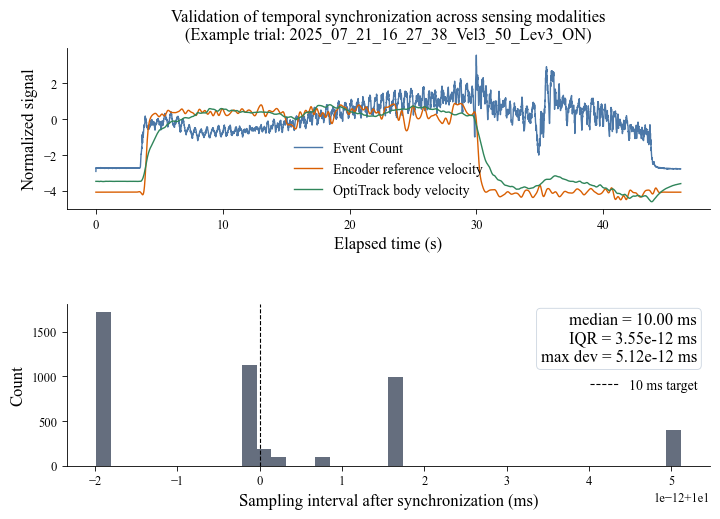

In [ ]:

example_trial_name = '2025_07_21_16_27_38_Vel3_50_Lev3_ON'
tr = trials[example_trial_name]
with h5py.File(h5_files[example_trial_name], "r") as f:
    tr["events"] = read_dataset(f, "events")
breaks = np.arange(tr["t"][0], tr["t"][-1], WINDOW_SIZE_S)
breaks_idx = np.searchsorted(tr["events"][:, 3], breaks)
tr["events_count"] = np.diff(breaks_idx, prepend=0)
t = tr["t"] - tr["t"][0]
lag, corr_peak, lags_s, corr = estimate_lag_seconds(t, tr["ref_velocity"][:, 0], tr["vel_body_xy"][:, 0])
dt_ms = 1e3 * np.diff(t)
dt_median = np.nanmedian(dt_ms)
dt_iqr = np.nanpercentile(dt_ms, 75) - np.nanpercentile(dt_ms, 25)
dt_max_dev = np.nanmax(np.abs(dt_ms - 1e3 * WINDOW_SIZE_S))
hist_xlim = (9.99999999999, 10.00000000001) if dt_max_dev <= 0.5 else (max(0, np.nanpercentile(dt_ms, 1)), np.nanpercentile(dt_ms, 99))

fig, axes = plt.subplots(2, 1,  sharex=False, constrained_layout=True)
fig.set_constrained_layout_pads(
    w_pad=0.1,
    h_pad=0.1,
    wspace=0.15,
    hspace=0.20
)

axes[0].plot(breaks, robust_zscore(tr["events_count"]), color=PALETTE["event"], label="Event Count")
axes[0].plot(t, robust_zscore(tr["ref_velocity"][:, 0]), color=PALETTE["encoder"], label="Encoder reference velocity")
axes[0].plot(t, robust_zscore(tr["vel_body_xy"][:, 0]), color=PALETTE["opti"], label="OptiTrack body velocity")
axes[0].set_ylabel("Normalized signal")
axes[0].set_xlabel("Elapsed time (s)")
axes[0].set_title(f"Validation of temporal synchronization across sensing modalities\n(Example trial: {example_trial_name})")
axes[0].legend(frameon=False, ncol=1, loc="best")

axes[1].hist(dt_ms[np.isfinite(dt_ms)], bins=40, color=PALETTE["gray"], alpha=0.85)
axes[1].axvline(1e3 * WINDOW_SIZE_S, color="black", lw=0.8, ls="--", label="10 ms target")
axes[1].ticklabel_format(axis="x", useOffset=True, style='sci', scilimits=(0,0))
axes[1].set_xlabel("Sampling interval after synchronization (ms)")
axes[1].set_ylabel("Count")
axes[1].text(
    0.98, 0.95,
    f"median = {dt_median:.2f} ms\nIQR = {dt_iqr:.2e} ms\nmax dev = {dt_max_dev:.2e} ms",
    transform=axes[1].transAxes,
    ha="right", va="top",
    bbox=dict(boxstyle="round,pad=0.25", fc="white", ec=PALETTE["light_gray"], lw=0.6),
)
axes[1].legend(frameon=False, loc="best")


for ax in axes:
    ax.spines[["top", "right"]].set_visible(False)

save_figure(fig, "fig_sensor_synchronization_enhanced", width_in=7.2, height_in=5.2, tight=False)



C:\Users\hazem\AppData\Local\Temp\ipykernel_18640\1469065112.py:20: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axes[1].legend(frameon=False, loc="upper left")


Dataset-level synchronization: 100.0% of trials had monotonic event timestamps and 100.0% had median sampling interval within ±0.1 ms of 10 ms. 270/270 trials had supporting encoder-to-OptiTrack correlation r > 0.6; their median lag was 0.0 ms and median r was 0.90.


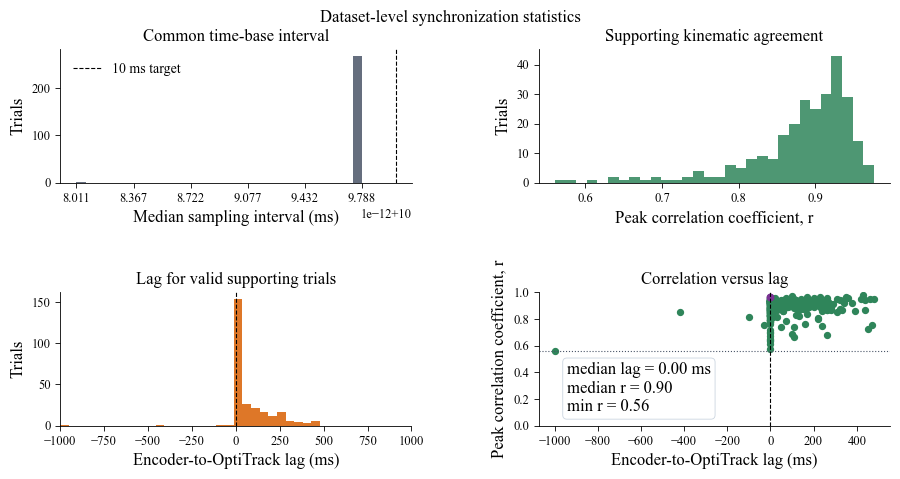

In [ ]:

fig, axes = plt.subplots(2, 2, figsize=(20, 10), constrained_layout=True)
axes = axes.ravel()

axes[0].hist(sync_table["grid_dt_median_ms"].dropna(), bins=30, color=PALETTE["gray"], alpha=0.85)
axes[0].axvline(10.0, color="black", lw=0.8, ls="--", label="10 ms target")
axes[0].set_xticks(np.linspace(sync_table["grid_dt_median_ms"].min(), sync_table["grid_dt_median_ms"].max(), 6))
axes[0].set_xlabel("Median sampling interval (ms)")
axes[0].set_ylabel("Trials")
axes[0].set_title("Common time-base interval")
axes[0].legend(frameon=False, loc="upper left")

axes[1].hist(sync_table["velocity_corr_peak"].dropna(), bins=30, color=PALETTE["opti"], alpha=0.85)
axes[1].set_xlabel("Peak correlation coefficient, r")
axes[1].set_ylabel("Trials")
axes[1].set_title("Supporting kinematic agreement")
axes[1].legend(frameon=False, loc="upper left")

valid_lag_values = sync_table.loc[valid_corr_trials, "encoder_to_opti_lag_ms"].dropna()
axes[2].hist(valid_lag_values, bins=30, color=PALETTE["encoder"], alpha=0.85)
axes[2].axvline(0, color="black", lw=0.8, ls="--")
axes[2].set_xlim(-1000, 1000)
axes[2].set_xlabel(f"Encoder-to-OptiTrack lag (ms)")
axes[2].set_ylabel("Trials")
axes[2].set_title("Lag for valid supporting trials")

low = ~valid_corr_trials
axes[3].scatter(
    sync_table.loc[~low, "encoder_to_opti_lag_ms"],
    sync_table.loc[~low, "velocity_corr_peak"],
    s=18,
    color=PALETTE["opti"],
    label=f"r > {CORRELATION_THRESHOLD}",
)
axes[3].scatter(
    sync_table.loc[sync_table["trial"] == example_trial_name, "encoder_to_opti_lag_ms"],
    sync_table.loc[sync_table["trial"] == example_trial_name, "velocity_corr_peak"],
    s=22,
    color=PALETTE["slip"],
    label="low correlation",
)
axes[3].axvline(valid_lag_values.median(), color="black", lw=0.8, ls="--")
axes[3].axhline(valid_corr.min(), color=PALETTE["gray"], lw=0.8, ls=":")
axes[3].set_xlabel("Encoder-to-OptiTrack lag (ms)")
axes[3].set_ylabel("Peak correlation coefficient, r")
axes[3].set_ylim(0, 1)
axes[3].set_title("Correlation versus lag")
axes[3].text(
    0.08, 0.08,
    f"median lag = {valid_lag_values.median():.2f} ms\nmedian r = {valid_corr.median():.2f}\nmin r = {valid_corr.min():.2f}",
    transform=axes[3].transAxes,
    ha="left", va="bottom", 
    bbox=dict(boxstyle="round,pad=0.25", fc="white", ec=PALETTE["light_gray"], lw=0.6),
)

for ax in axes:
    ax.spines[["top", "right"]].set_visible(False)

fig.suptitle("Dataset-level synchronization statistics", y=1.02, fontsize=12)
fig.set_constrained_layout_pads(
    w_pad=0.1,
    h_pad=0.1,
    wspace=0.15,
    hspace=0.20
)
save_figure(fig, "fig_sensor_synchronization_dataset_summary", width_in=9, height_in=4.6, tight=False)



## 3. Ground-Truth Validation

This section supports label trustworthiness by reporting the measurement chain, kinematic agreement between wheel encoder command and OptiTrack body velocity, and numerical consistency of the saved slip label.

In [10]:
def boxplot_stats(data):
    data = np.asarray(data)
    data = data[np.isfinite(data)]
    return (
        f"Med={np.nanmedian(data):.2f}, "
        f"IQR={np.nanpercentile(data,75)-np.nanpercentile(data,25):.2f}, "
        f"N={len(data)}"
    )
    
    
def fetch_slip_lvl(slip_lon_by_eff_level, slip_lat_by_eff_level):
    for tr in tqdm(trials.values(), desc="Fetching trial-level slip ratios", unit="trial"):
        level = tr["metadata"]["soil_class"] 
        eff = tr["metadata"]["efficiency_condition"]


        slip_lon = np.asarray(tr["slip"][:, 0], dtype=float)
        slip_lat = np.asarray(tr["slip"][:, 1], dtype=float)
        
        moving_forward = np.isfinite(slip_lon) & (np.abs(tr["ref_velocity"][:,0]) > 0.01) & (np.abs(tr["ref_velocity"][:,1]) < 0.04)
        turning = np.isfinite(slip_lat) & (np.abs(tr["ref_velocity"][:,1]) > 0.04)

        slip_lon = slip_lon[moving_forward]
        slip_lat = slip_lat[turning]

        if len(slip_lon) > 0:
            # One value per trial
            slip_lon_by_eff_level[level][eff].append(np.nanmedian(slip_lon))

        if len(slip_lat) > 0:
            # One value per trial
            slip_lat_by_eff_level[level][eff].append(np.nanmedian(slip_lat))
    
def fetch_slip(slip_lon_by_efficiency, slip_lat_by_efficiency):
    for tr in tqdm(trials.values(), desc="Fetching trial-level slip ratios", unit="trial"):
        eff = tr["metadata"]["efficiency_condition"]

        if eff == "100":
            label = "100%"
        elif eff == "50":
            label = "50%"
        elif eff == "25":
            label = "25%"
        else:
            continue

        slip_lon = np.asarray(tr["slip"][:, 0], dtype=float)
        slip_lat = np.asarray(tr["slip"][:, 1], dtype=float)
        
        moving_forward = np.isfinite(slip_lon) & (np.abs(tr["ref_velocity"][:,0]) > 0.01) & (np.abs(tr["ref_velocity"][:,1]) < 0.04)
        turning = np.isfinite(slip_lat) & (np.abs(tr["ref_velocity"][:,1]) > 0.04)

        slip_lon = slip_lon[moving_forward]
        slip_lat = slip_lat[turning]

        if len(slip_lon) > 0:
            # One value per trial
            slip_lon_by_efficiency[label].append(np.nanmedian(slip_lon))

        if len(slip_lat) > 0:
            # One value per trial
            slip_lat_by_efficiency[label].append(np.nanmedian(slip_lat))
def recompute_reference_velocity(motor_rpm):
    motor_rpm = np.asarray(motor_rpm, dtype=float)
    wheel_signs = np.array([+1, +1, -1, -1])
    use_wheels = np.array([0, 2])
    corrected_rpm = motor_rpm[:, use_wheels] * wheel_signs[use_wheels]
    wheel_speeds = corrected_rpm * (2 * np.pi / 60.0) * WHEEL_RADIUS_M
    v_left = wheel_speeds[:, 0]
    v_right = wheel_speeds[:, 1]
    ref = np.zeros((len(motor_rpm), 2))
    ref[:, 0] = (v_left + v_right) / 2.0
    ref[:, 1] = ((v_left - v_right) / (2 * HALF_TRACK_WIDTH_M)) * RADIUS_CURVATURE_M
    return ref


def ground_truth_metrics(tr):
    ref = tr["ref_velocity"][:, 0]
    opti = tr["vel_body_xy"][:, 0]
    moving = np.isfinite(ref) & np.isfinite(opti) & (np.abs(ref) > np.nanpercentile(np.abs(ref), 25))
    err = opti[moving] - ref[moving]
    rpm_ref = recompute_reference_velocity(tr["motor_rpm"])
    return {
        "trial": tr["name"],
        "velocity_rmse_m_s": float(np.sqrt(np.nanmean(err**2))),
        "velocity_mae_m_s": float(np.nanmean(np.abs(err))),
        "velocity_bias_m_s": float(np.nanmean(err)),
        "velocity_abs_error_p95_m_s": float(np.nanpercentile(np.abs(err), 95)),
        "velocity_pearson_r": pearson_r(ref[moving], opti[moving]),
        "ref_velocity_from_rpm_mae_m_s": float(np.nanmean(np.abs(tr["ref_velocity"][:, 0] - rpm_ref[:, 0]))),
    }

gt_table = pd.DataFrame([
    ground_truth_metrics(tr)
    for tr in tqdm(trials.values(), desc="Computing ground-truth metrics", unit="trial")
])
gt_table.to_csv(FIGURE_DIR / "ground_truth_validation_metrics.csv", index=False)
metadata_table = pd.DataFrame([{"item": k, "evidence": v} for k, v in VALIDATION_METADATA.items()])
metadata_table.to_csv(FIGURE_DIR / "ground_truth_metadata_to_report.csv", index=False)
display(metadata_table)
gt_table


Computing ground-truth metrics: 100%|██████████| 270/270 [00:00<00:00, 1092.21trial/s]


,item,evidence
0,OptiTrack accuracy,positional precision of ±0.15 mm
1,OptiTrack sampling,Measured in this notebook from the processed 1...
2,Wheel encoder resolution,0.01 dps
3,Wheel encoder calibration,Wheel radius = 0.10 m; track half-width = 0.22...
4,Slip computation,OptiTrack body-frame velocity and encoder refe...


,trial,velocity_rmse_m_s,velocity_mae_m_s,velocity_bias_m_s,velocity_abs_error_p95_m_s,velocity_pearson_r,ref_velocity_from_rpm_mae_m_s
0,2025_07_17_17_19_17_Vel1_Lev3_ON,0.006086,0.004951,0.002045,0.010230,0.876481,0.000920
1,2025_07_21_10_22_29_Vel1_Lev3_ON,0.004941,0.003572,0.000197,0.009794,0.919804,0.000639
2,2025_07_21_10_43_41_Vel1_Lev3_ON,0.005183,0.003531,-0.000169,0.010778,0.905691,0.000668
3,2025_07_21_10_52_21_Vel1_Lev3_OFF,0.004973,0.003540,-0.000080,0.011357,0.867214,0.000691
4,2025_07_21_11_02_18_Vel1_Lev3_OFF,0.006191,0.003915,-0.000329,0.013123,0.876880,0.000647
...,...,...,...,...,...,...,...
265,2025_07_30_23_32_49_Vel5_25_Lev1_ON,0.085431,0.081226,-0.073583,0.118310,0.612736,0.005997
266,2025_07_30_23_34_43_Vel5_25_Lev1_ON,0.075522,0.069015,-0.063255,0.118683,0.751229,0.006096
267,2025_07_30_23_38_08_Vel5_25_Lev1_OFF,0.073769,0.068425,-0.049717,0.112839,0.748020,0.006240
268,2025_07_30_23_40_43_Vel5_25_Lev1_OFF,0.077813,0.066861,-0.062014,0.149028,0.603275,0.006474


Fetching trial-level slip ratios: 100%|██████████| 270/270 [00:00<00:00, 4621.73trial/s]


Ground-truth validation: for moving samples, encoder reference velocity and OptiTrack body velocity had r = 0.75, RMSE = 0.037 m s^-1, MAE = 0.027 m s^-1, bias = 0.022 m s^-1, and 95th percentile absolute residual = 0.082 m s^-1.


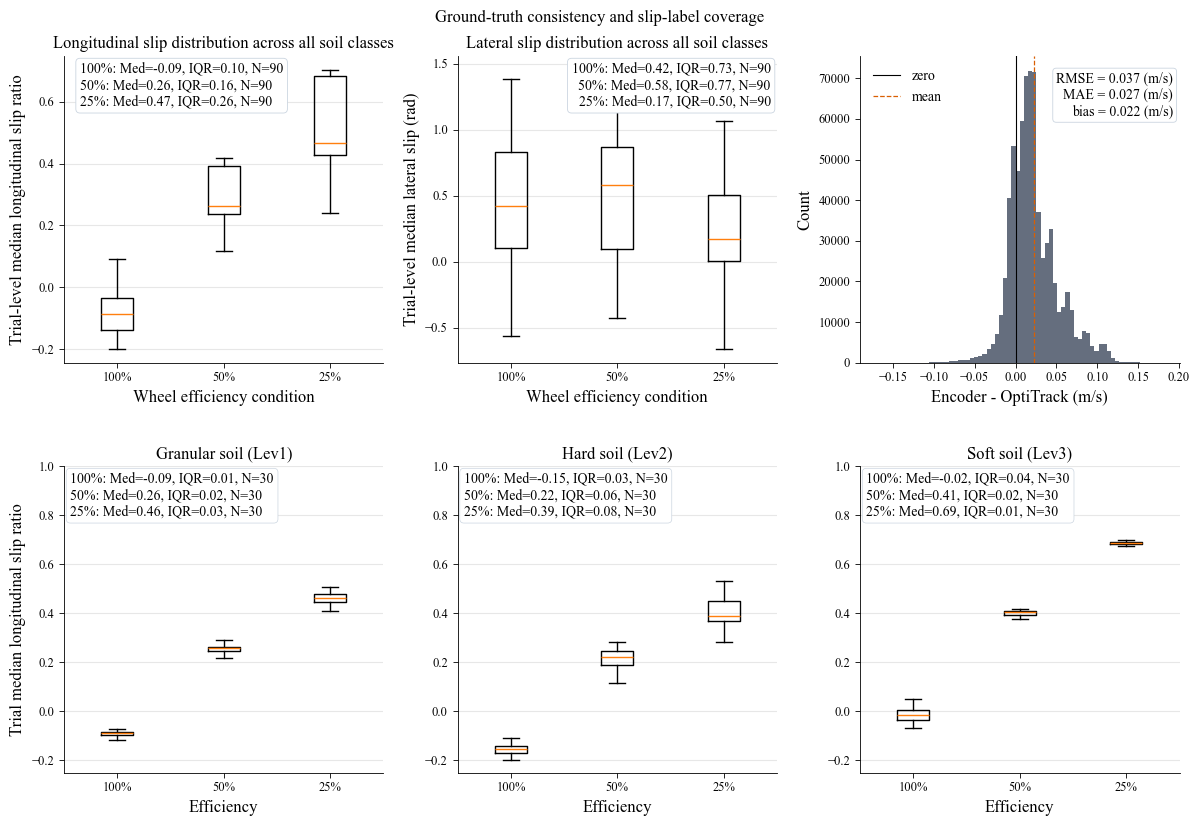

In [ ]:

all_ref = np.concatenate([tr["ref_velocity"][:, 0] for tr in trials.values()])
all_opti = np.concatenate([tr["vel_body_xy"][:, 0] for tr in trials.values()])
# One value per experiment, not one value per synchronized sample
levels = ["Lev1", "Lev2", "Lev3"]
efficiencies = ["100", "50", "25"]

slip_lon_by_eff_level = {lvl: {eff: [] for eff in efficiencies} for lvl in levels}
slip_lat_by_eff_level = {lvl: {eff: [] for eff in efficiencies} for lvl in levels}

fetch_slip_lvl(slip_lon_by_eff_level, slip_lat_by_eff_level)

slip_lon_by_efficiency = {"100%": [], "50%": [], "25%": []}
slip_lat_by_efficiency = {"100%": [], "50%": [], "25%": []}

fetch_slip(slip_lon_by_efficiency, slip_lat_by_efficiency)


text_lon = (
    f"100%: {boxplot_stats(slip_lon_by_efficiency["100%"])}\n"
        f"50%: {boxplot_stats(slip_lon_by_efficiency["50%"])}\n"
        f"25%: {boxplot_stats(slip_lon_by_efficiency["25%"])}"
)

text_lat = (
    f"100%: {boxplot_stats(slip_lat_by_efficiency["100%"])}\n"
        f"50%: {boxplot_stats(slip_lat_by_efficiency["50%"])}\n"
        f"25%: {boxplot_stats(slip_lat_by_efficiency["25%"])}"
)

moving = np.isfinite(all_ref) & np.isfinite(all_opti) & (np.abs(all_ref) > 0.01) # Only consider samples where the rover is moving
ref_m = all_ref[moving]
opti_m = all_opti[moving]
residual = ref_m - opti_m
vel_rmse = np.sqrt(np.nanmean(residual**2))
vel_mae = np.nanmean(np.abs(residual))
vel_bias = np.nanmean(residual)
vel_p95 = np.nanpercentile(np.abs(residual), 95)
vel_r = pearson_r(ref_m, opti_m)

fig, axes = plt.subplots(2, 3, figsize=(12, 12), constrained_layout=True)

axes[0,0].boxplot(
    [
        slip_lon_by_efficiency["100%"],
        slip_lon_by_efficiency["50%"],
        slip_lon_by_efficiency["25%"]
    ],
    tick_labels=["100%", "50%", "25%"],
    showfliers=False
)
axes[0,0].set_xlabel("Wheel efficiency condition")
axes[0,0].set_ylabel("Trial-level median longitudinal slip ratio")
axes[0,0].set_title("Longitudinal slip distribution across all soil classes")
axes[0,0].grid(axis="y", alpha=0.3)
axes[0,0].text(
    0.05, 0.98,
    text_lon,
    transform=axes[0,0].transAxes,
    ha="left",
    va="top",
    fontsize=10,
    bbox=dict(
        boxstyle="round,pad=0.3",
        fc="white",
        ec=PALETTE["light_gray"],
        lw=0.6
    )
)

axes[0,1].boxplot(
    [
        slip_lat_by_efficiency["100%"],
        slip_lat_by_efficiency["50%"],
        slip_lat_by_efficiency["25%"]
    ],
    tick_labels=["100%", "50%", "25%"],
    showfliers=False
)
axes[0,1].set_xlabel("Wheel efficiency condition")
axes[0,1].set_ylabel("Trial-level median lateral slip (rad)")
axes[0,1].set_title("Lateral slip distribution across all soil classes")
axes[0,1].grid(axis="y", alpha=0.3)
axes[0,1].text(
    0.98, 0.98,
    text_lat,
    transform=axes[0,1].transAxes,
    ha="right",
    va="top",
    fontsize=10,
    bbox=dict(
        boxstyle="round,pad=0.3",
        fc="white",
        ec=PALETTE["light_gray"],
        lw=0.6
    )
)


axes[0,2].hist(residual[np.isfinite(residual)], bins=70, color=PALETTE["gray"], alpha=0.85)
axes[0,2].axvline(0, color="black", lw=0.8, label="zero")
axes[0,2].axvline(vel_bias, color=PALETTE["encoder"], lw=0.9, ls="--", label="mean")
axes[0,2].set_xlabel(f"Encoder - OptiTrack ({UNIT_VEL})")
axes[0,2].set_ylabel("Count")
axes[0,2].text(
    0.98, 0.95,
    f"RMSE = {vel_rmse:.3f} ({UNIT_VEL})\nMAE = {vel_mae:.3f} ({UNIT_VEL})\nbias = {vel_bias:.3f} ({UNIT_VEL})",
    transform=axes[0,2].transAxes,
    ha="right", va="top",
    fontsize=10,
    bbox=dict(boxstyle="round,pad=0.25", fc="white", ec=PALETTE["light_gray"], lw=0.6),
)
axes[0,2].legend(frameon=False, loc="upper left")

for j, level in enumerate(levels):
    #################################################
    # Longitudinal
    #################################################
    if level == "Lev1":
        title = "Granular soil (Lev1)"
    elif level == "Lev2":
        title = "Hard soil (Lev2)"
    elif level == "Lev3":
        title = "Soft soil (Lev3)"
    ax = axes[1,j]
    data = [
        slip_lon_by_eff_level[level]["100"],
        slip_lon_by_eff_level[level]["50"],
        slip_lon_by_eff_level[level]["25"]
    ]
    ax.boxplot(
        data,
        tick_labels=["100%","50%","25%"],
        showfliers=False
    )
    ax.set_title(f"{title}")
    ax.set_ylim(-0.25, 1.0)
    if j == 0:
        ax.set_ylabel("Trial median longitudinal slip ratio")

    ax.set_xlabel("Efficiency")

    ax.grid(axis="y", alpha=0.3)
    text = (
        f"100%: {boxplot_stats(data[0])}\n"
        f"50%: {boxplot_stats(data[1])}\n"
        f"25%: {boxplot_stats(data[2])}"
    )
    ax.text(
        0.02,
        0.98,
        text,
        transform=ax.transAxes,
        va="top",
        fontsize=10,
        bbox=dict(
            boxstyle="round",
            fc="white",
            ec=PALETTE["light_gray"],
            lw=0.5
        )
    )

    # #################################################
    # # Lateral
    # #################################################
    # ax = axes[2,j]
    # data = [
    #     slip_lat_by_eff_level[level]["100"],
    #     slip_lat_by_eff_level[level]["50"],
    #     slip_lat_by_eff_level[level]["25"]
    # ]
    # ax.boxplot(
    #     data,
    #     tick_labels=["100%","50%","25%"],
    #     showfliers=False
    # )
    # if j == 0:
    #     ax.set_ylabel("Trial median lateral slip (rad)")

    # ax.set_xlabel("Efficiency")
    # ax.set_title(f"{title}")
    # ax.set_ylim(-0.5, 1.5)
    # ax.grid(axis="y", alpha=0.3)
    # text = (
    #     f"100%: {boxplot_stats(data[0])}\n"
    #     f"50%: {boxplot_stats(data[1])}\n"
    #     f"25%: {boxplot_stats(data[2])}"
    # )
    # ax.text(
    #     0.02,
    #     0.98,
    #     text,
    #     transform=ax.transAxes,
    #     va="top",
    #     fontsize=10,
    #     bbox=dict(
    #         boxstyle="round",
    #         fc="white",
    #         ec=PALETTE["light_gray"],
    #         lw=0.5
    #     )
    # )


for ax in axes.ravel():
    ax.spines[["top", "right"]].set_visible(False)

fig.suptitle("Ground-truth consistency and slip-label coverage", y=1.02, fontsize=12)

fig.set_constrained_layout_pads(
    w_pad=0.1,
    h_pad=0.1,
    wspace=0.05,
    hspace=0.10
)
save_figure(fig, "fig_ground_truth_validation_enhanced", width_in=12, height_in=8, tight=False)


print(
    f"Ground-truth validation: for moving samples, encoder reference velocity and OptiTrack body velocity had "
    f"r = {vel_r:.2f}, RMSE = {vel_rmse:.3f} m s^-1, MAE = {vel_mae:.3f} m s^-1, "
    f"bias = {vel_bias:.3f} m s^-1, and 95th percentile absolute residual = {vel_p95:.3f} m s^-1."
)


## 4. Dataset Consistency and Repeatability

Trials are grouped by the command suffix after the leading timestamp, for example `Vel1_Lev3_ON`. Repeated trials are time-normalized before overlay so that identical commands can be compared even when files have different dates and start times.

In [12]:
def available_repeat_groups(trials):
    groups = {}
    for name, tr in tqdm(trials.items(), desc="Scanning repeat groups", unit="trial"):
        groups.setdefault(tr["suffix"], []).append(name)
    return {k: v for k, v in groups.items() if len(v) >= 2}

auto_groups = available_repeat_groups(trials)
configured_groups = {
    key: [name for name in names if name in trials]
    for key, names in REPEATABILITY_GROUPS.items()
}
configured_groups = {k: v for k, v in configured_groups.items() if len(v) >= 2}
repeat_groups = configured_groups or auto_groups

if not repeat_groups:
    print("No repeated trial groups were found. Add trial names to REPEATABILITY_GROUPS after loading the data.")
else:
    pd.DataFrame([{"group": k, "n_trials": len(v), "trials": "; ".join(v)} for k, v in repeat_groups.items()])

Scanning repeat groups: 100%|██████████| 270/270 [00:00<00:00, 536711.89trial/s]


In [13]:
from scipy import signal

def estimate_trial_shift(t_ref, v_ref, t_cmp, v_cmp, max_shift_s=10.0, dt_s=0.01):
    """
    Estimate time shift between two repeated trials with possibly different lengths.
    Positive lag means comparison trial occurs later than reference trial.
    """

    t_ref = np.asarray(t_ref, dtype=float)
    v_ref = np.asarray(v_ref, dtype=float)
    t_cmp = np.asarray(t_cmp, dtype=float)
    v_cmp = np.asarray(v_cmp, dtype=float)

    valid_ref = np.isfinite(t_ref) & np.isfinite(v_ref)
    valid_cmp = np.isfinite(t_cmp) & np.isfinite(v_cmp)

    t_ref = t_ref[valid_ref]
    v_ref = v_ref[valid_ref]
    t_cmp = t_cmp[valid_cmp]
    v_cmp = v_cmp[valid_cmp]

    # Common overlap interval
    t0 = max(t_ref.min(), t_cmp.min())
    t1 = min(t_ref.max(), t_cmp.max())

    if t1 <= t0:
        return np.nan, np.nan

    t_common = np.arange(t0, t1, dt_s)

    if len(t_common) < 20:
        return np.nan, np.nan

    v_ref_i = np.interp(t_common, t_ref, v_ref)
    v_cmp_i = np.interp(t_common, t_cmp, v_cmp)

    x = signal.detrend(v_ref_i)
    y = signal.detrend(v_cmp_i)

    x = x - np.mean(x)
    y = y - np.mean(y)

    denom = np.sqrt(np.sum(x**2) * np.sum(y**2))
    if denom <= np.finfo(float).eps:
        return np.nan, np.nan

    corr = signal.correlate(y, x, mode="full")
    lags = signal.correlation_lags(len(y), len(x), mode="full")
    lag_s = lags * dt_s

    corr = corr / denom

    keep = np.abs(lag_s) <= max_shift_s
    corr = corr[keep]
    lag_s = lag_s[keep]

    if len(corr) == 0:
        return np.nan, np.nan

    idx = np.nanargmax(corr)

    return float(lag_s[idx]), float(corr[idx])

def normalized_time(tr):
    t = tr["t"] - tr["t"][0]
    duration = t[-1] if t[-1] > 0 else 1.0
    return t / duration

def interpolate_repeat_signals(names, n_grid=500):
    common_tau = np.linspace(0, 1, n_grid)
    signals = {"body_x": [], "ref_x": [], "slip_x": [], "rpm_m1": []}
    for name in names:
        tr = trials[name]
        tau = normalized_time(tr)
        signals["body_x"].append(np.interp(common_tau, tau, tr["vel_body_xy"][:, 0]))
        signals["ref_x"].append(np.interp(common_tau, tau, tr["ref_velocity"][:, 0]))
        signals["slip_x"].append(np.interp(common_tau, tau, tr["slip"][:, 0]))
        signals["rpm_m1"].append(np.interp(common_tau, tau, tr["motor_rpm"][:, 0]))
    return common_tau, {k: np.vstack(v) for k, v in signals.items()}

def repeatability_metrics(group_name, names):
    rows = []
    _, signals = interpolate_repeat_signals(names)
    labels = {
        "body_x": "OptiTrack body velocity",
        "ref_x": "Encoder reference velocity",
        "slip_x": "Slip ratio",
        "rpm_m1": "Motor RPM",
    }
    for signal_name, arr in signals.items():
        mean_abs = np.nanmean(np.abs(arr))
        rows.append({
            "group": group_name,
            "signal": signal_name,
            "signal_label": labels[signal_name],
            "n_trials": len(names),
            "mean_between_trial_sd": float(np.nanmean(np.nanstd(arr, axis=0))),
            "normalized_cv": float(np.nanmean(np.nanstd(arr, axis=0)) / mean_abs) if mean_abs > 0 else np.nan,
        })
    return rows

repeat_rows = []
for group_name, names in tqdm(repeat_groups.items(), desc="Computing repeatability metrics", unit="group"):
    repeat_rows.extend(repeatability_metrics(group_name, names))
repeatability_table = pd.DataFrame(repeat_rows)
repeatability_table.to_csv(FIGURE_DIR / "repeatability_metrics.csv", index=False)
repeatability_table


Computing repeatability metrics: 100%|██████████| 90/90 [00:00<00:00, 695.12group/s]


,group,signal,signal_label,n_trials,mean_between_trial_sd,normalized_cv
0,Vel1_Lev3_ON,body_x,OptiTrack body velocity,3,0.001601,0.078026
1,Vel1_Lev3_ON,ref_x,Encoder reference velocity,3,0.002615,0.130884
2,Vel1_Lev3_ON,slip_x,Slip ratio,3,0.153118,0.865106
3,Vel1_Lev3_ON,rpm_m1,Motor RPM,3,0.455229,0.176423
4,Vel1_Lev3_OFF,body_x,OptiTrack body velocity,3,0.002069,0.101153
...,...,...,...,...,...,...
355,Vel5_25_Lev1_ON,rpm_m1,Motor RPM,3,5.542725,0.433188
356,Vel5_25_Lev1_OFF,body_x,OptiTrack body velocity,3,0.015257,0.274467
357,Vel5_25_Lev1_OFF,ref_x,Encoder reference velocity,3,0.031567,0.337341
358,Vel5_25_Lev1_OFF,slip_x,Slip ratio,3,0.278119,0.609276


Plotting Vel5_Lev1_ON: 100%|██████████| 3/3 [00:00<00:00, 347.01trial/s]

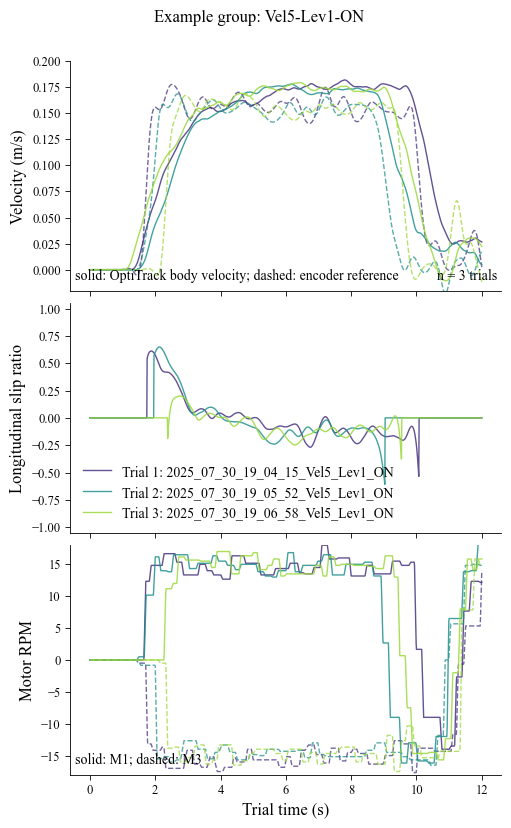

In [20]:
def recompute_slip(tr):
    ref = tr["ref_velocity"][:, 0]
    opti = tr["vel_body_xy"][:, 0]
    slip = np.zeros_like(ref)
    moving = np.isfinite(ref) & np.isfinite(opti) & (np.abs(ref) > 0.09)
    slip[moving] = (ref[moving] - opti[moving]) / ref[moving]
    return slip
if repeat_groups:
    # group_name, names = next(iter(repeat_groups.items()))
    group_name, names = "Vel5_Lev1_ON", repeat_groups["Vel5_Lev1_ON"]
    common_tau, signals = interpolate_repeat_signals(names)
    fig, axes = plt.subplots(3, 1, figsize=(7.2, 4.9), sharex=True)
    colors = plt.cm.viridis(np.linspace(0.15, 0.85, len(names)))
    stop_time = 12
    
    t = {name: trials[name]["t"] - trials[name]["t"][0] for name in names}
    reference = names[0]
    ref_t = t[reference]
    ref_v = trials[reference]["vel_body_xy"][:,0]
    lags = {name: 0.0 for name in names}
    r = {name: 1.0 for name in names}
    
    for name in names[1:]:
        lags[name], r[name] = estimate_trial_shift(
            ref_t,
            ref_v,
            t[name],
            trials[name]["vel_body_xy"][:,0]
        )
    idx = 0
    for color, name in tqdm(list(zip(colors, names)), desc=f"Plotting {group_name}", unit="trial"):
        tr = trials[name]  
        idx += 1
        t[name] = t[name] - lags[name]
        label = f"Trial {idx}: {name}"
        axes[0].plot(t[name][t[name] <= stop_time], tr["vel_body_xy"][t[name] <= stop_time, 0], color=color, alpha=0.85)
        axes[0].plot(t[name][t[name] <= stop_time], tr["ref_velocity"][t[name] <= stop_time, 0], color=color, ls="--", alpha=0.75)
        axes[1].plot(t[name][t[name] <= stop_time], recompute_slip(tr)[t[name] <= stop_time], color=color, label=label, alpha=0.85)
        axes[2].plot(t[name][t[name] <= stop_time], tr["motor_rpm"][t[name] <= stop_time, 0], color=color, alpha=0.85)
        axes[2].plot(t[name][t[name] <= stop_time], tr["motor_rpm"][t[name] <= stop_time, 2], color=color, ls="--", alpha=0.75)

    body_mean = np.nanmean(signals["body_x"], axis=0)
    body_sd = np.nanstd(signals["body_x"], axis=0)
    slip_mean = np.nanmean(signals["slip_x"], axis=0)
    slip_sd = np.nanstd(signals["slip_x"], axis=0)

    axes[0].set_ylabel(f"Velocity ({UNIT_VEL})")
    axes[0].text(0.01, 0.05, "solid: OptiTrack body velocity; dashed: encoder reference", transform=axes[0].transAxes, fontsize=10)
    axes[0].text(0.99, 0.05, f"n = {len(names)} trials", transform=axes[0].transAxes, ha="right", fontsize=10)
    axes[0].set_ylim(-0.02, 0.2)

    axes[1].legend(frameon=False, ncol=1, loc="best")
    axes[1].set_ylabel("Longitudinal slip ratio")
    axes[1].set_ylim(-1.05, 1.05)
    # axes[1].set_xlim(0, np.max([t[name][-1] for name in names]))

    axes[2].set_ylabel("Motor RPM")
    axes[2].set_xlabel("Trial time (s)")
    axes[2].text(0.01, 0.05, "solid: M1; dashed: M3", transform=axes[2].transAxes, fontsize=10)
    axes[2].set_ylim(-18, 18)
    
    fig.suptitle(f"Example group: {group_name.replace('_', '-')}", y=1.02, fontsize=12)
    for ax in axes:
        ax.spines[["top", "right"]].set_visible(False)
        
    

    save_figure(fig, "fig_repeatability_example_enhanced", width_in=5, height_in=8)

    

## 5. Dataset Pipeline and Dataset-Level Statistics


Dataset coverage: 270 trials were loaded, covering 3 soil classes, 5 velocity levels, and 3 efficiency conditions. The validation set contains 1,067,884 finite longitudinal slip-ratio labels.


,category,level,count
0,Soil class,Lev1,9.000000e+01
1,Soil class,Lev2,9.000000e+01
2,Soil class,Lev3,9.000000e+01
3,Lighting condition,OFF,1.350000e+02
4,Lighting condition,ON,1.350000e+02
5,Velocity level,Vel1,5.400000e+01
6,Velocity level,Vel2,5.400000e+01
7,Velocity level,Vel3,5.400000e+01
8,Velocity level,Vel4,5.400000e+01
9,Velocity level,Vel5,5.400000e+01


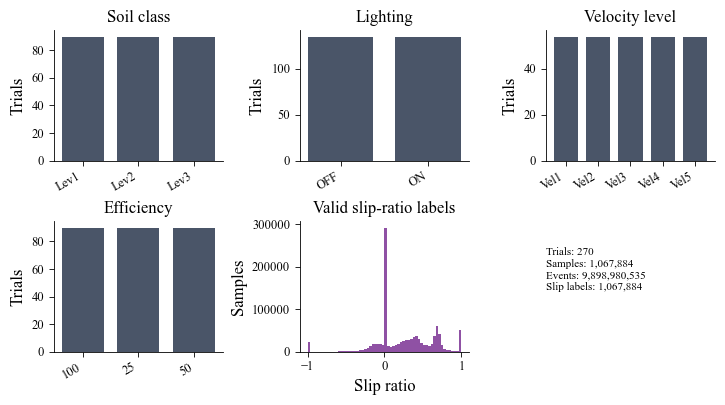

In [16]:

def dataset_statistics_table(summary, trials):
    rows = []
    for col, label in [
        ("soil_class", "Soil class"),
        ("lighting", "Lighting condition"),
        ("velocity_level", "Velocity level"),
        ("efficiency_condition", "Efficiency condition"),
    ]:
        counts = summary[col].fillna("Unknown").value_counts().sort_index()
        for level, count in counts.items():
            rows.append({"category": label, "level": level, "count": int(count)})
    slip_values = np.concatenate([tr["slip"][:, 0] for tr in trials.values()])
    slip_values = slip_values[np.isfinite(slip_values)]
    rows.extend([
        {"category": "Slip ratio", "level": "valid labels", "count": int(len(slip_values))},
        {"category": "Slip ratio", "level": "median", "count": float(np.nanmedian(slip_values))},
        {"category": "Slip ratio", "level": "IQR", "count": float(np.nanpercentile(slip_values, 75) - np.nanpercentile(slip_values, 25))},
    ])
    return pd.DataFrame(rows), slip_values

stats_table, slip_values = dataset_statistics_table(summary, trials)
stats_table.to_csv(FIGURE_DIR / "dataset_statistics_summary.csv", index=False)

fig, axes = plt.subplots(2, 3, figsize=(7.2, 4.0))
axes = axes.ravel()
for ax, col, title in zip(
    axes[:4],
    ["soil_class", "lighting", "velocity_level", "efficiency_condition"],
    ["Soil class", "Lighting", "Velocity level", "Efficiency"],
):
    counts = summary[col].fillna("Unknown").value_counts().sort_index()
    ax.bar(range(len(counts)), counts.values, color=PALETTE["gray"], width=0.75)
    ax.set_title(title)
    ax.set_ylabel("Trials")
    ax.set_xticks(range(len(counts)))
    ax.set_xticklabels(counts.index, rotation=30, ha="right")
    ax.spines[["top", "right"]].set_visible(False)

axes[4].hist(slip_values, bins=60, color=PALETTE["slip"], alpha=0.85)
axes[4].set_title("Valid slip-ratio labels")
axes[4].set_xlabel("Slip ratio")
axes[4].set_ylabel("Samples")
axes[4].spines[["top", "right"]].set_visible(False)
axes[5].axis("off")
axes[5].text(
    0, 0.8,
    f"Trials: {len(summary)}\nSamples: {summary['samples'].sum():,}\nEvents: {summary['events'].sum():,}\nSlip labels: {len(slip_values):,}",
    ha="left", va="top", fontsize=8,
)

save_figure(fig, "fig_dataset_statistics", width_in=7.2, height_in=4.0)
print(
    f"Dataset coverage: {len(summary)} trials were loaded, covering {summary['soil_class'].nunique()} soil classes, "
    f"{summary['velocity_level'].nunique()} velocity levels, and {summary['efficiency_condition'].nunique()} efficiency conditions. "
    f"The validation set contains {len(slip_values):,} finite longitudinal slip-ratio labels."
)
stats_table


Repeatability: 90 repeated command groups comprising 270 trials were identified. The full between-trial standard-deviation and normalized-CV table was saved to repeatability_metrics_summary.csv.


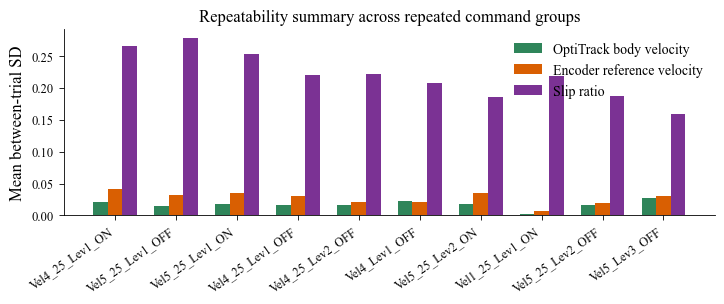

In [17]:

if repeat_groups and not repeatability_table.empty:
    pivot = repeatability_table.pivot_table(index="group", columns="signal", values="mean_between_trial_sd", aggfunc="mean")
    required = ["body_x", "ref_x", "slip_x"]
    available = [c for c in required if c in pivot.columns]
    plot_df = pivot[available].copy()
    plot_df["score"] = plot_df.mean(axis=1)
    plot_df = plot_df.sort_values("score", ascending=False).head(10).drop(columns="score")

    fig, ax = plt.subplots(figsize=(7.2, 3.0))
    x = np.arange(len(plot_df))
    width = 0.24
    labels = {"body_x": "OptiTrack body velocity", "ref_x": "Encoder reference velocity", "slip_x": "Slip ratio"}
    colors = [PALETTE["opti"], PALETTE["encoder"], PALETTE["slip"]]
    for i, col in enumerate(plot_df.columns):
        ax.bar(x + (i - (len(plot_df.columns) - 1) / 2) * width, plot_df[col].values, width=width, label=labels[col], color=colors[i])
    ax.set_xticks(x)
    ax.set_xticklabels(plot_df.index, rotation=35, ha="right")
    ax.set_ylabel("Mean between-trial SD")
    ax.set_title("Repeatability summary across repeated command groups")
    ax.legend(frameon=False, ncol=1, loc="upper right")
    ax.spines[["top", "right"]].set_visible(False)
    save_figure(fig, "fig_repeatability_summary", width_in=7.2, height_in=3.0)

    n_groups = len(repeat_groups)
    n_repeated_trials = sum(len(v) for v in repeat_groups.values())
    print(
        f"Repeatability: {n_groups} repeated command groups comprising {n_repeated_trials} trials were identified. "
        f"The full between-trial standard-deviation and normalized-CV table was saved to repeatability_metrics_summary.csv."
    )
else:
    print("Repeatability summary was not generated because no repeated groups were available.")


## 6. Manuscript-Ready Validation Statements


In [29]:

print("Sensor synchronization statement")
print(
    f"The dataset uses a common synchronized {WINDOW_SIZE_S*1000:.0f} ms time base across sensing modalities. "
    f"Across {len(sync_table)} trials, the median synchronized sampling interval was "
    f"{sync_table['grid_dt_median_ms'].median():.3f} ms with median IQR "
    f"{sync_table['grid_dt_iqr_ms'].median():.3f} ms. "
    f"{dataset_sync_summary.loc[0, 'percentage_monotonic_event_timestamps']:.1f}% of trials had monotonic event timestamps, "
    f"and {dataset_sync_summary.loc[0, 'percentage_median_dt_within_0p1_ms_of_10_ms']:.1f}% had median sampling interval "
    f"within ±0.1 ms of 10 ms. Encoder-to-OptiTrack agreement is reported as supporting evidence only: "
    f"{int(dataset_sync_summary.loc[0, 'n_valid_correlation_trials'])}/{len(sync_table)} trials had r > {CORRELATION_THRESHOLD}, "
    f"with median lag {dataset_sync_summary.loc[0, 'median_lag_ms_valid_corr_trials']:.1f} ms and median peak correlation "
    f"r = {dataset_sync_summary.loc[0, 'median_peak_correlation_valid_trials']:.2f} among those trials. "
    "Non-zero lag in some trials is expected because encoder velocity represents wheel motion whereas OptiTrack measures "
    "actual rover body motion during wheel-soil interaction."
)
print("\nGround-truth statement")
print(
    f"For moving samples, encoder reference velocity and OptiTrack body velocity had median RMSE "
    f"{gt_table['velocity_rmse_m_s'].median():.3f} m s^-1, median MAE "
    f"{gt_table['velocity_mae_m_s'].median():.3f} m s^-1, median bias "
    f"{gt_table['velocity_bias_m_s'].median():.3f} m s^-1, and median Pearson r "
    f"{gt_table['velocity_pearson_r'].median():.2f}."
)
print("\nSlip-label reproducibility statement")

if repeat_groups and not repeatability_table.empty:
    print("\nRepeatability statement")
    body_sd = repeatability_table.loc[repeatability_table['signal'] == 'body_x', 'mean_between_trial_sd'].median()
    ref_sd = repeatability_table.loc[repeatability_table['signal'] == 'ref_x', 'mean_between_trial_sd'].median()
    slip_sd = repeatability_table.loc[repeatability_table['signal'] == 'slip_x', 'mean_between_trial_sd'].median()
    print(
        f"Across {len(repeat_groups)} repeated command groups, the median mean between-trial SD was "
        f"{body_sd:.3f} m s^-1 for OptiTrack body velocity, {ref_sd:.3f} m s^-1 for encoder reference velocity, "
        f"and {slip_sd:.3f} for longitudinal slip ratio."
    )
print("\nDataset coverage statement")
print(
    f"The loaded dataset contains {len(summary)} trials, {summary['samples'].sum():,} synchronized samples, "
    f"and {summary['events'].sum():,} event-camera events across {summary['soil_class'].nunique()} soil classes, "
    f"{summary['velocity_level'].nunique()} velocity levels, and {summary['efficiency_condition'].nunique()} efficiency conditions."
)
print("\nOutput files")
for p in sorted(FIGURE_DIR.glob("*")):
    print(p)


Sensor synchronization statement
The dataset uses a common synchronized 10 ms time base across sensing modalities. Across 270 trials, the median synchronized sampling interval was 10.000 ms with median IQR 0.000 ms. 100.0% of trials had monotonic event timestamps, and 100.0% had median sampling interval within ±0.1 ms of 10 ms. Encoder-to-OptiTrack agreement is reported as supporting evidence only: 270/270 trials had r > 0.5603600173165357, with median lag 0.0 ms and median peak correlation r = 0.90 among those trials. Non-zero lag in some trials is expected because encoder velocity represents wheel motion whereas OptiTrack measures actual rover body motion during wheel-soil interaction.

Ground-truth statement
For moving samples, encoder reference velocity and OptiTrack body velocity had median RMSE 0.029 m s^-1, median MAE 0.024 m s^-1, median bias -0.016 m s^-1, and median Pearson r 0.87.

Slip-label reproducibility statement

Repeatability statement
Across 90 repeated command group